# Chapter 12 — Unsupervised Learning: a Deeper Dive

This notebook accompanies **Chapter 12** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

Unsupervised learning has no response variable — the goal is to discover structure in the data itself.  Three techniques are developed:

1. **K-means clustering** — partition data into $K$ groups by alternating between assigning points to the nearest centroid (E-step) and recomputing centroids (M-step).  Choose $K$ using the *elbow method* or *gap statistic*.
2. **Gaussian Mixture Model (GMM) + EM** — a soft, probabilistic version of K-means.  The EM algorithm alternates between computing *responsibilities* (E-step) and updating component means, covariances, and weights (M-step).
3. **PCA** — find the linear encoder–decoder that minimises reconstruction loss.  The optimal encoder directions are the eigenvectors of the sample covariance matrix.

All three are implemented from scratch and applied to a dataset of American English vowel sounds, characterised by their acoustic formant frequencies.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal

rng = np.random.default_rng(0)

---
## The data

The dataset records 2371 vowel utterances by native American English speakers.  Each utterance is a syllable such as *heed*, *hid*, *hod*, etc.  The two standardised acoustic features we'll use are:

- $X_1$ = **Backness** (negative F2 Lobanov): how far back the tongue is
- $X_2$ = **Height** (negative F1 Lobanov): how high the tongue is

Speakers are tagged by **dialect region** (Mid-Atlantic, Midland, New England, North, South, West).  Vowels from different phonemes form visually distinct clouds in the $(X_1, X_2)$ plane — a natural clustering problem.

> **Book link — §11.5.2 and §12.1.**  The same 2D features appear in Figure 11.6 (all dialects) and Figure 12.1 (three dialect subsets).

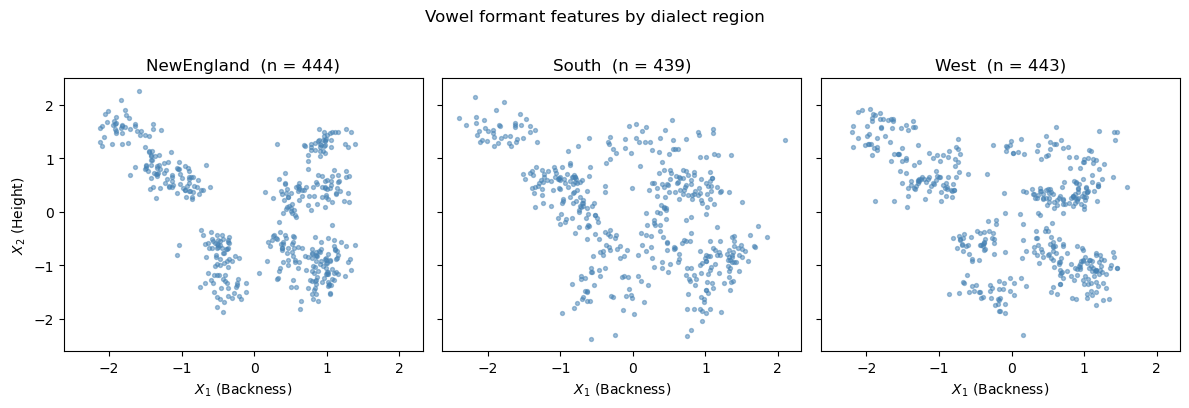

Total utterances: 2659,  NewEngland subset: 444
Vowel targets: ['frogs', 'had', 'hayed', 'head', 'heed', 'hid', 'hod', 'hoed', 'hood', 'hud', 'logs', 'whod']


In [15]:
df   = pd.read_csv('../DATA/Vowels_Processed.csv')
ne   = df[df['Dialect'] == 'NewEngland'][['Backness', 'Height']].values
X_all = df[['Backness', 'Height']].values

dialects  = ['NewEngland', 'South', 'West']
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, d in zip(axes, dialects):
    sub = df[df['Dialect'] == d]
    ax.scatter(sub['Backness'], sub['Height'], s=8, alpha=0.5, color='steelblue')
    ax.set_title(f'{d}  (n = {len(sub)})')
    ax.set_xlabel('$X_1$ (Backness)')
axes[0].set_ylabel('$X_2$ (Height)')
plt.suptitle('Vowel formant features by dialect region', y=1.01)
plt.tight_layout()
plt.show()

print(f"Total utterances: {len(df)},  NewEngland subset: {len(ne)}")
print(f"Vowel targets: {sorted(df['Target'].unique())}")

---
## K-means clustering

K-means minimises total within-cluster inertia $W = \sum_{k=1}^K \sum_{i \in C_k} \|\boldsymbol{x}_i - \bar{\boldsymbol{x}}_k\|^2$ by alternating:

**(E-step)** Assign each point to the nearest centroid:
$$z_{ik} = 1 \;\text{ if }\; k = \arg\min_j \|\boldsymbol{x}_i - \boldsymbol{\mu}_j\|^2.$$

**(M-step)** Update each centroid to the mean of its assigned points:
$$\boldsymbol{\mu}_k \leftarrow \frac{\sum_i z_{ik}\, \boldsymbol{x}_i}{\sum_i z_{ik}}.$$

The algorithm converges to a **local minimum**, so it is run several times with random initialisations and the best result (lowest inertia) is kept.

> **Book link — Box 12.1 (K-means algorithm), Figure 12.2.**

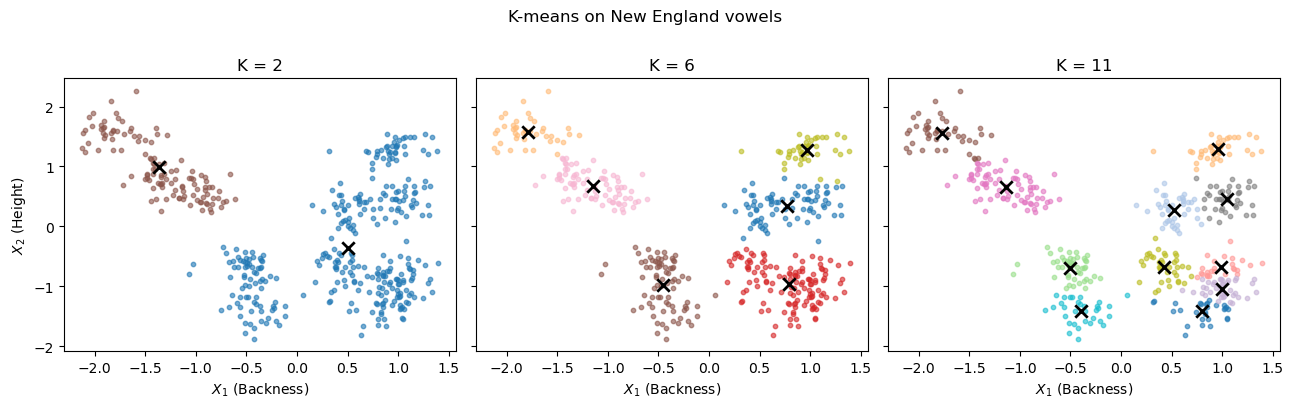

In [16]:
def kmeans(X, K, n_init=10, max_iter=300, rng=rng):
    """K-means with multiple random restarts. Returns (labels, centroids, inertia)."""
    n, p  = X.shape
    best  = (None, None, np.inf)
    for _ in range(n_init):
        mu = X[rng.choice(n, K, replace=False)].copy()
        labels = np.zeros(n, dtype=int)
        for _ in range(max_iter):
            # E-step
            dists  = np.linalg.norm(X[:, None, :] - mu[None, :, :], axis=2)
            new_lbl = dists.argmin(axis=1)
            if np.all(new_lbl == labels):
                break
            labels = new_lbl
            # M-step
            for k in range(K):
                pts = X[labels == k]
                if len(pts) > 0:
                    mu[k] = pts.mean(axis=0)
        inertia = sum(np.sum((X[labels == k] - mu[k])**2) for k in range(K))
        if inertia < best[2]:
            best = (labels, mu, inertia)
    return best


# Reproduce Figure 12.2 — New England vowels, K = 2, 6, 11
K_vals  = [2, 6, 11]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
cmap = plt.get_cmap('tab20')
for ax, K in zip(axes, K_vals):
    labels, mu, W = kmeans(ne, K)
    for k in range(K):
        pts = ne[labels == k]
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.6, color=cmap(k / K))
    ax.scatter(mu[:, 0], mu[:, 1], marker='x', s=80, color='black', linewidths=2)
    ax.set_title(f'K = {K}')
    ax.set_xlabel('$X_1$ (Backness)')
axes[0].set_ylabel('$X_2$ (Height)')
plt.suptitle('K-means on New England vowels', y=1.01)
plt.tight_layout()
plt.show()

---
## Choosing K — elbow method and gap statistic

The **elbow method** plots $\log W(K)$ against $K$ and looks for a kink where the rate of decrease slows.  The **gap statistic** (§12.1.2) makes the comparison quantitative by comparing the real inertia to the inertia of a null dataset with no clusters:

$$g(K) = \log\frac{W_1}{W_K} - \frac{2}{p}\log K.$$

The null model expects inertia $W_K^{\text{null}} = \frac{npV^{2/p}}{12} K^{-2/p}$, where $V$ is the volume of the bounding hypercube.  We choose $K$ at the **peak** of $g(K)$.

> **Book link — §12.1.2, Figures 12.3–12.4.**  The New England data has a clear peak near $K = 11$, consistent with the 10 distinct phoneme categories (one pair of phonemes merges in some dialects).

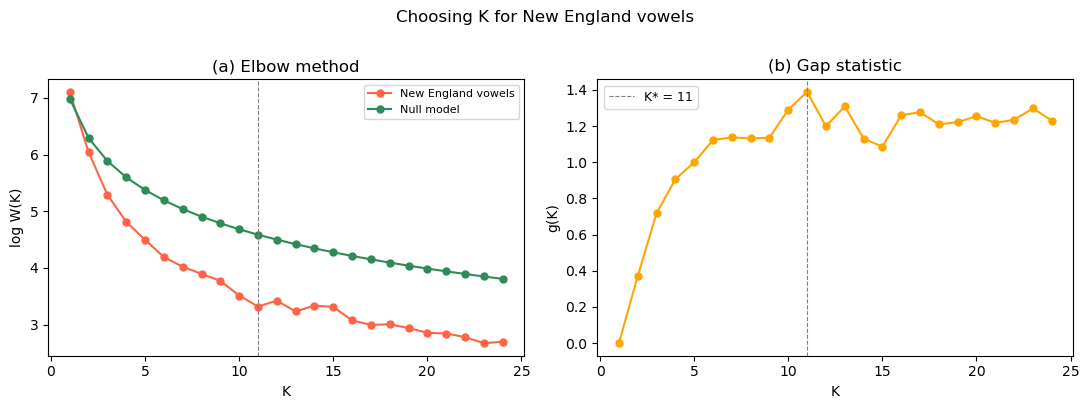

Gap statistic peaks at K = 11


In [17]:
K_range = range(1, 25)
inertias = []
for K in K_range:
    _, _, W = kmeans(ne, K, n_init=5)
    inertias.append(W)

inertias = np.array(inertias)
log_W    = np.log(inertias)

# Gap statistic: g(K) = log(W_1/W_K) - (2/p)*log(K)
n, p = ne.shape
gap  = (log_W[0] - log_W) - (2 / p) * np.log(np.array(list(K_range)))
gap[0] = 0   # define g(1) = 0

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(K_range, log_W, 'o-', color='tomato', markersize=5, label='New England vowels')
# Overlay null model: log W_null(K) = log(n*p*V^(2/p)/12) - (2/p)*log(K)
V   = np.prod(ne.max(axis=0) - ne.min(axis=0))
log_W_null = np.log(n * p * V**(2/p) / 12) - (2/p)*np.log(np.array(list(K_range)))
ax.plot(K_range, log_W_null, 'o-', color='seagreen', markersize=5, label='Null model')
ax.axvline(11, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('K')
ax.set_ylabel('log W(K)')
ax.set_title('(a) Elbow method')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(K_range, gap, 'o-', color='orange', markersize=5)
best_K = int(np.argmax(gap)) + 1
ax.axvline(best_K, color='grey', linestyle='--', linewidth=0.8, label=f'K* = {best_K}')
ax.set_xlabel('K')
ax.set_ylabel('g(K)')
ax.set_title('(b) Gap statistic')
ax.legend(fontsize=9)

plt.suptitle('Choosing K for New England vowels', y=1.01)
plt.tight_layout()
plt.show()
print(f"Gap statistic peaks at K = {best_K}")

---
## Gaussian Mixture Models and the EM algorithm

A K-component GMM models the density as
$$f_X(\boldsymbol{x}; \boldsymbol{\theta}) = \sum_{k=1}^K \pi_k \mathcal{N}(\boldsymbol{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k).$$

K-means is recovered in the limit where all $\boldsymbol{\Sigma}_k = \sigma^2 \boldsymbol{I}$ with $\sigma \to 0$: soft responsibilities become hard assignments.  The **EM algorithm** (Box 12.3) alternates:

**(E-step)** Compute **responsibilities** — the posterior probability that $\boldsymbol{x}_i$ came from component $k$:
$$r_{ik} = \frac{\pi_k \mathcal{N}(\boldsymbol{x}_i \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_j \pi_j \mathcal{N}(\boldsymbol{x}_i \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}.$$

**(M-step)** Update parameters using responsibility-weighted statistics:
$$n_k = \sum_i r_{ik}, \quad \boldsymbol{\mu}_k = \frac{1}{n_k}\sum_i r_{ik}\boldsymbol{x}_i, \quad \boldsymbol{\Sigma}_k = \frac{1}{n_k}\sum_i r_{ik}(\boldsymbol{x}_i - \boldsymbol{\mu}_k)(\boldsymbol{x}_i - \boldsymbol{\mu}_k)^T, \quad \pi_k = \frac{n_k}{n}.$$

> **Book link — §12.2.3, Box 12.3.** The E-step is the expectation step; the M-step is the maximisation step.

In [18]:
def gmm_em(X, K, n_init=5, max_iter=200, tol=1e-4, rng=rng):
    """EM for a full-covariance GMM.  Returns (responsibilities, mus, Sigmas, pis, log_lik)."""
    n, p = X.shape
    best = None
    best_ll = -np.inf

    for _ in range(n_init):
        # Initialise with K-means
        labels, mus, _ = kmeans(X, K, n_init=1, rng=rng)
        Sigmas = np.array([np.cov(X[labels == k].T) + 1e-4*np.eye(p)
                           if (labels == k).sum() > 1 else np.eye(p) for k in range(K)])
        pis    = np.array([(labels == k).mean() for k in range(K)], dtype=float)
        ll_prev = -np.inf

        for _ in range(max_iter):
            # E-step
            log_r = np.array([
                np.log(pis[k] + 1e-300) + multivariate_normal.logpdf(X, mus[k], Sigmas[k])
                for k in range(K)
            ]).T   # (n, K)
            log_r -= log_r.max(axis=1, keepdims=True)
            r = np.exp(log_r)
            r /= r.sum(axis=1, keepdims=True)

            # log-likelihood
            ll = np.sum(np.log(
                np.array([pis[k] * multivariate_normal.pdf(X, mus[k], Sigmas[k])
                           for k in range(K)]).T.sum(axis=1) + 1e-300))

            # M-step
            nk = r.sum(axis=0)   # (K,)
            mus    = (r.T @ X) / nk[:, None]
            Sigmas = np.array([
                (r[:, k:k+1] * (X - mus[k])).T @ (X - mus[k]) / nk[k] + 1e-4*np.eye(p)
                for k in range(K)])
            pis = nk / n

            if abs(ll - ll_prev) < tol:
                break
            ll_prev = ll

        if ll > best_ll:
            best_ll = ll
            best = (r, mus, Sigmas, pis, ll)

    return best


# Fit K=11 GMM to New England vowels
K_fit = 11
r_fit, mus_fit, Sigmas_fit, pis_fit, ll_fit = gmm_em(ne, K_fit)
print(f"GMM K={K_fit}: log-likelihood = {ll_fit:.1f}")

GMM K=11: log-likelihood = -715.2


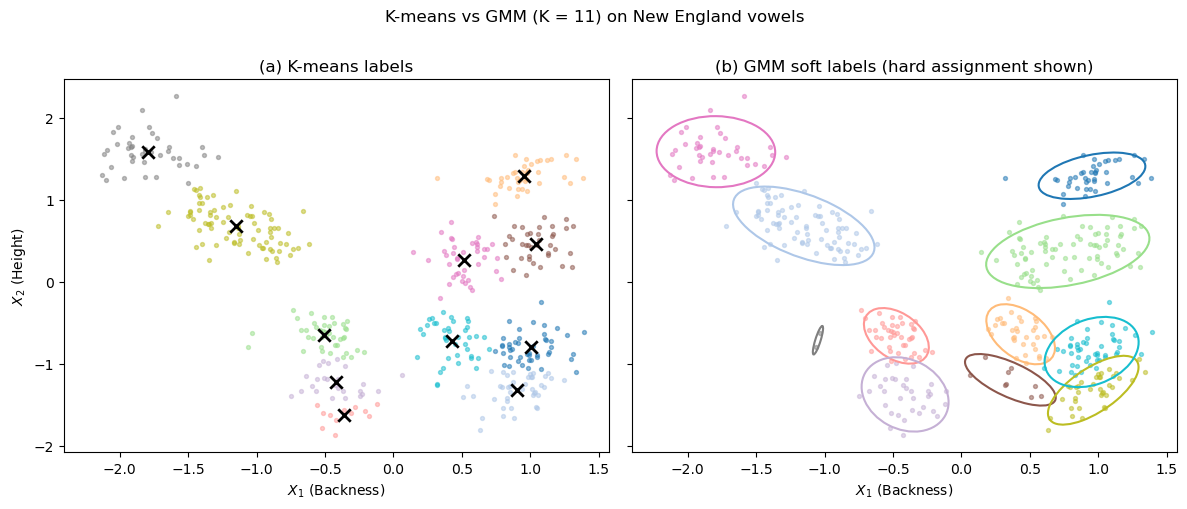

In [19]:
def draw_ellipse(ax, mu, Sigma, n_std=2, **kwargs):
    """Draw a covariance ellipse at n_std standard deviations."""
    vals, vecs = np.linalg.eigh(Sigma)
    order  = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle  = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse(mu, width, height, angle=angle, **kwargs))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
labels_hard = r_fit.argmax(axis=1)

for ax, title, col_fn in zip(
        axes,
        ['(a) K-means labels', '(b) GMM soft labels (hard assignment shown)'],
        [lambda k: plt.get_cmap('tab20')(k / K_fit),
         lambda k: plt.get_cmap('tab20')(k / K_fit)]):
    if 'GMM' in title:
        for k in range(K_fit):
            pts = ne[labels_hard == k]
            ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.5, color=col_fn(k))
        for k in range(K_fit):
            draw_ellipse(ax, mus_fit[k], Sigmas_fit[k], n_std=2,
                         fill=False, edgecolor=col_fn(k), linewidth=1.5)
    else:
        km_lbl, km_mu, _ = kmeans(ne, K_fit)
        for k in range(K_fit):
            pts = ne[km_lbl == k]
            ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.5, color=col_fn(k))
        ax.scatter(km_mu[:, 0], km_mu[:, 1], marker='x', s=80, color='black', linewidths=2)
    ax.set_title(title)
    ax.set_xlabel('$X_1$ (Backness)')

axes[0].set_ylabel('$X_2$ (Height)')
plt.suptitle(f'K-means vs GMM (K = {K_fit}) on New England vowels', y=1.01)
plt.tight_layout()
plt.show()

---
## Dimensionality reduction and PCA

An **encoder** maps $\boldsymbol{x} \in \mathbb{R}^p$ to a lower-dimensional code $\boldsymbol{z} \in \mathbb{R}^M$; a **decoder** maps it back.  The reconstruction loss is
$$J(\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=1}^n \|\boldsymbol{x}_i - \tilde{\boldsymbol{x}}_i\|^2.$$

**Principal Component Analysis (PCA)** is the special case of linear encoder and decoder.  The optimal encoder directions are the eigenvectors of the sample covariance matrix $C = \frac{1}{n}\tilde{X}^T \tilde{X}$ (where $\tilde{X}$ is mean-centred).  Stacking the top $M$ eigenvectors as columns of $B \in \mathbb{R}^{p \times M}$:

$$\text{encode}(\boldsymbol{x}) = B^T(\boldsymbol{x} - \boldsymbol{\mu}), \qquad \text{decode}(\boldsymbol{z}) = B\boldsymbol{z} + \boldsymbol{\mu}.$$

The **proportion of variance explained** by the first $M$ components is $\sum_{m=1}^M \lambda_m / \sum_{k=1}^p \lambda_k$.

> **Book link — §12.3, Figures 12.10–12.11.**  The book motivates dimensionality reduction using handwritten digit images: 28×28 pixel images live in a 784-dimensional space, but the 'squiggle space' of plausible digits is a low-dimensional manifold within it.  We use the 8×8 scikit-learn digits dataset (64 features) for the same demonstration at a manageable scale.

Digits dataset: 1797 images, 64 features (8×8 pixels), 10 classes


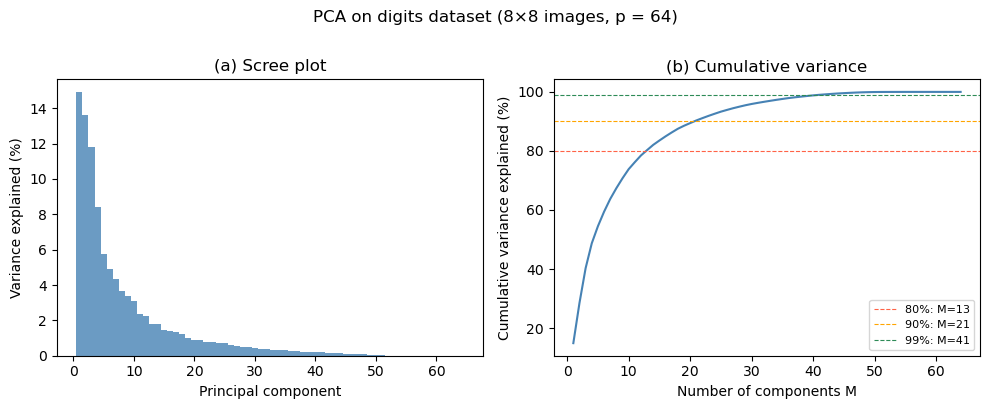

In [20]:
from sklearn.datasets import load_digits

digits = load_digits()
X_dig  = digits.data.astype(float)   # (1797, 64) — pixel intensities 0–16
y_dig  = digits.target                # digit labels 0–9
n_dig, p_dig = X_dig.shape
print(f"Digits dataset: {n_dig} images, {p_dig} features (8×8 pixels), {len(set(y_dig))} classes")

def pca(X, M):
    """PCA from scratch: returns (B, z, eigenvalues, reconstruction_loss)."""
    mu       = X.mean(axis=0)
    X_c      = X - mu
    C        = X_c.T @ X_c / len(X)
    eigvals, eigvecs = np.linalg.eigh(C)      # ascending order
    idx      = eigvals.argsort()[::-1]        # sort descending
    eigvals  = eigvals[idx]
    B        = eigvecs[:, idx[:M]]            # p × M
    z        = X_c @ B                       # n × M  (codes)
    X_rec    = z @ B.T + mu                  # n × p  (reconstructions)
    loss     = np.mean(np.sum((X - X_rec)**2, axis=1))
    return B, z, eigvals, loss

# ---- Scree plot ----
_, _, eigvals_dig, _ = pca(X_dig, p_dig)
prop_var = eigvals_dig / eigvals_dig.sum()
cum_var  = np.cumsum(prop_var)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(range(1, p_dig + 1), prop_var * 100, color='steelblue', alpha=0.8, width=1)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('(a) Scree plot')
axes[1].plot(range(1, p_dig + 1), cum_var * 100, color='steelblue', linewidth=1.5)
for thresh, col in [(80, 'tomato'), (90, 'orange'), (99, 'seagreen')]:
    m = np.searchsorted(cum_var, thresh / 100) + 1
    axes[1].axhline(thresh, color=col, linestyle='--', linewidth=0.8, label=f'{thresh}%: M={m}')
axes[1].set_xlabel('Number of components M')
axes[1].set_ylabel('Cumulative variance explained (%)')
axes[1].set_title('(b) Cumulative variance')
axes[1].legend(fontsize=8)
plt.suptitle('PCA on digits dataset (8×8 images, p = 64)', y=1.01)
plt.tight_layout()
plt.show()

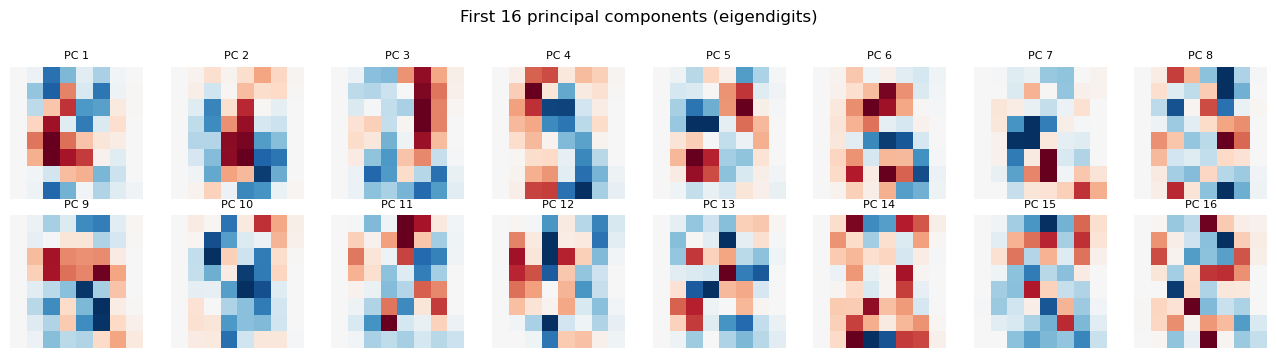

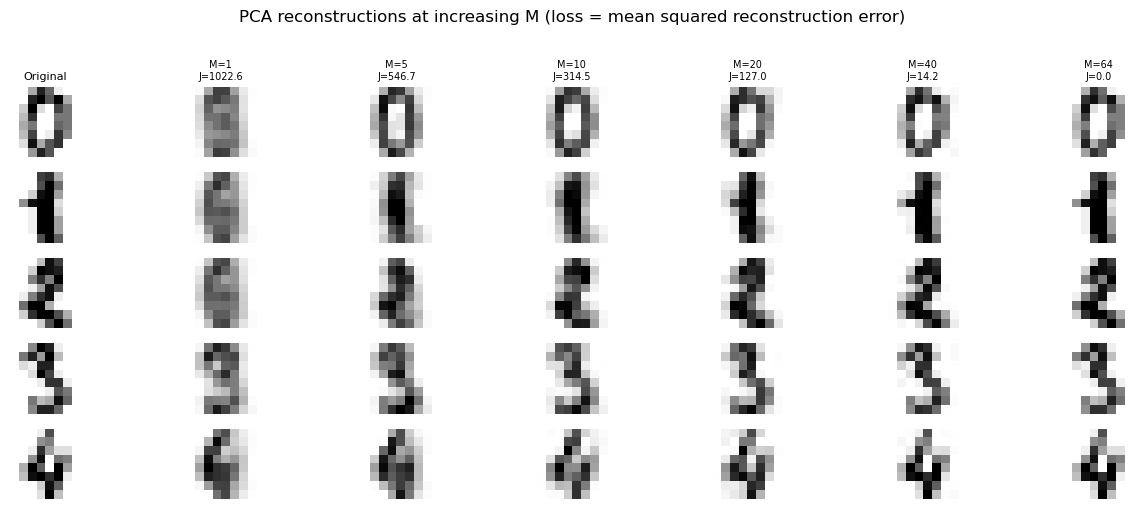

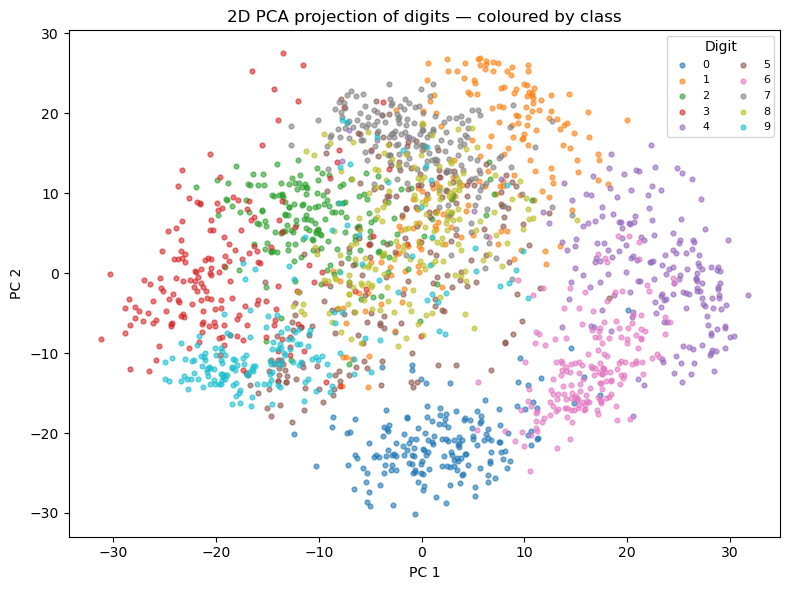

In [21]:
# ---- Eigendigits: the first 16 principal components ----
B_full, _, _, _ = pca(X_dig, p_dig)

fig, axes = plt.subplots(2, 8, figsize=(13, 3.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(B_full[:, i].reshape(8, 8), cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    ax.set_title(f'PC {i+1}', fontsize=8)
    ax.axis('off')
plt.suptitle('First 16 principal components (eigendigits)', y=1.01)
plt.tight_layout()
plt.show()

# ---- Reconstruction at different M values ----
M_vals = [1, 5, 10, 20, 40, 64]
# Pick one example of each digit 0–4
examples = [np.where(y_dig == d)[0][0] for d in range(5)]

fig, axes = plt.subplots(len(examples), len(M_vals) + 1,
                          figsize=(13, 5))
for row, idx in enumerate(examples):
    # Original
    ax = axes[row, 0]
    ax.imshow(X_dig[idx].reshape(8, 8), cmap='gray_r')
    ax.axis('off')
    if row == 0:
        ax.set_title('Original', fontsize=8)
    axes[row, 0].set_ylabel(f'digit {y_dig[idx]}', fontsize=8, rotation=0,
                             labelpad=28, va='center')
    # Reconstructions
    for col, M in enumerate(M_vals, start=1):
        B_m, z_m, _, loss_m = pca(X_dig, M)
        x_rec = (X_dig[idx] - X_dig.mean(axis=0)) @ B_m @ B_m.T + X_dig.mean(axis=0)
        axes[row, col].imshow(x_rec.reshape(8, 8), cmap='gray_r',
                               vmin=0, vmax=16)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'M={M}\nJ={loss_m:.1f}', fontsize=7)

plt.suptitle('PCA reconstructions at increasing M (loss = mean squared reconstruction error)',
             y=1.01)
plt.tight_layout()
plt.show()

# ---- 2D projection coloured by digit class ----
_, z2_dig, _, _ = pca(X_dig, 2)
cmap10 = plt.get_cmap('tab10')

fig, ax = plt.subplots(figsize=(8, 6))
for d in range(10):
    mask = y_dig == d
    ax.scatter(z2_dig[mask, 0], z2_dig[mask, 1], s=12, alpha=0.6,
               color=cmap10(d / 10), label=str(d))
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('2D PCA projection of digits — coloured by class')
ax.legend(title='Digit', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1 — K-means sensitivity to initialisation

Run K-means with $K = 6$ on the NewEngland vowel data 20 times with different random seeds, recording the final inertia each time.  Plot a histogram of the inertia values.  How much does the result vary?  Comment on what this means for using K-means in practice.

### Exercise 2 — EM convergence

Modify the `gmm_em` function to record the log-likelihood at each iteration for a single run.  Plot log-likelihood against iteration number for $K = 6$ and $K = 11$ on the NewEngland data.  Confirm that the log-likelihood is non-decreasing.

### Exercise 3 — PCA reconstruction identity

Compute the reconstruction loss $J$ (eq. 12.16) for $M = 1, 10, 20, 40, 64$ components on the digits dataset.  Confirm that $J = \sum_{m=M+1}^{p} \lambda_m$ — the loss equals the sum of the discarded eigenvalues.

In [ ]:
# Exercise 1 — your answer here

# Exercise 2 — your answer here

# Exercise 3 — your answer here

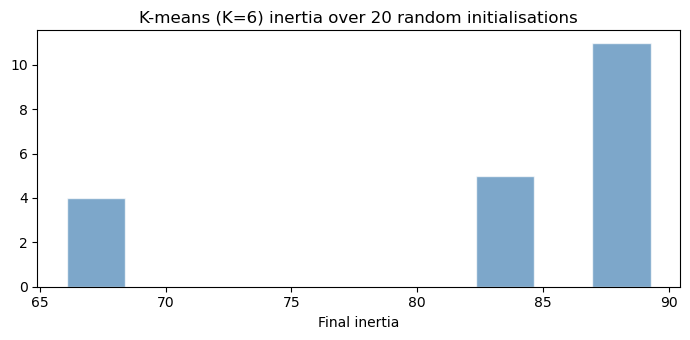

Min: 66.1,  Max: 89.3,  Range: 23.2
Practical advice: always use multiple restarts and keep the best result.


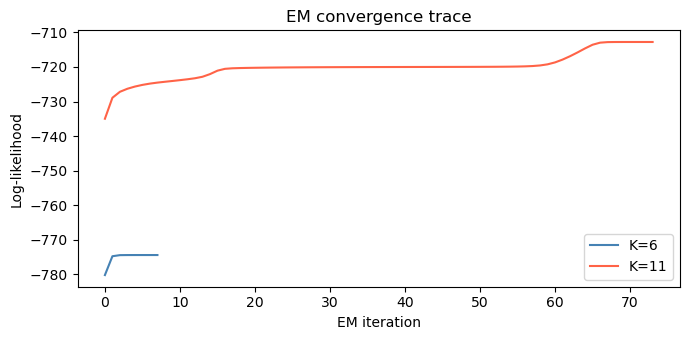


Exercise 3 — Reconstruction loss vs. discarded eigenvalues (digits):
M= 1: J=1022.5714,  sum discarded λ=1022.5714
M=10: J=314.5150,  sum discarded λ=314.5150
M=20: J=126.9926,  sum discarded λ=126.9926
M=40: J=14.1742,  sum discarded λ=14.1742
M=64: J=0.0000,  sum discarded λ=0.0000


In [22]:
# --- Solutions ---

# Exercise 1
K_ex  = 6
inert = [kmeans(ne, K_ex, n_init=1, rng=np.random.default_rng(s))[2] for s in range(20)]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(inert, bins=10, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_xlabel('Final inertia')
ax.set_title(f'K-means (K={K_ex}) inertia over 20 random initialisations')
plt.tight_layout(); plt.show()
print(f"Min: {min(inert):.1f},  Max: {max(inert):.1f},  Range: {max(inert)-min(inert):.1f}")
print("Practical advice: always use multiple restarts and keep the best result.")

# Exercise 2
def gmm_em_trace(X, K, max_iter=200, tol=1e-4, rng=rng):
    n, p   = X.shape
    labels, mus, _ = kmeans(X, K, n_init=1, rng=rng)
    Sigmas = np.array([np.cov(X[labels==k].T) + 1e-4*np.eye(p)
                       if (labels==k).sum()>1 else np.eye(p) for k in range(K)])
    pis    = np.array([(labels==k).mean() for k in range(K)], dtype=float)
    lls    = []
    for _ in range(max_iter):
        log_r = np.array([np.log(pis[k]+1e-300) +
                           multivariate_normal.logpdf(X, mus[k], Sigmas[k])
                           for k in range(K)]).T
        log_r -= log_r.max(axis=1, keepdims=True)
        r = np.exp(log_r); r /= r.sum(axis=1, keepdims=True)
        ll = np.sum(np.log(np.array(
            [pis[k]*multivariate_normal.pdf(X, mus[k], Sigmas[k])
             for k in range(K)]).T.sum(axis=1)+1e-300))
        lls.append(ll)
        nk = r.sum(axis=0); mus = (r.T @ X)/nk[:,None]
        Sigmas = np.array([(r[:,k:k+1]*(X-mus[k])).T@(X-mus[k])/nk[k]+1e-4*np.eye(p)
                            for k in range(K)])
        pis = nk/n
        if len(lls)>1 and abs(lls[-1]-lls[-2])<tol: break
    return lls

fig, ax = plt.subplots(figsize=(7, 3.5))
for K, col in [(6, 'steelblue'), (11, 'tomato')]:
    ll_trace = gmm_em_trace(ne, K)
    ax.plot(ll_trace, color=col, label=f'K={K}')
ax.set_xlabel('EM iteration'); ax.set_ylabel('Log-likelihood')
ax.set_title('EM convergence trace'); ax.legend()
plt.tight_layout(); plt.show()

# Exercise 3
print("\nExercise 3 — Reconstruction loss vs. discarded eigenvalues (digits):")
_, _, eigvals_dig_full, _ = pca(X_dig, p_dig)
for M in [1, 10, 20, 40, 64]:
    _, _, _, loss = pca(X_dig, M)
    discarded = eigvals_dig_full[M:].sum()
    print(f"M={M:2d}: J={loss:.4f},  sum discarded λ={discarded:.4f}")